### Import all packages need in the cell below

In [10]:
import Pkg
Pkg.add("JuMP")
Pkg.add("HiGHS")
Pkg.add("Ipopt")
Pkg.add("Plots")
Pkg.add("MathOptInterface")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\morai\.julia\environments\v1.12\Manifest.toml`
   Resolving pac

In [16]:
using Plots
using JuMP
using Ipopt
using HiGHS

# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

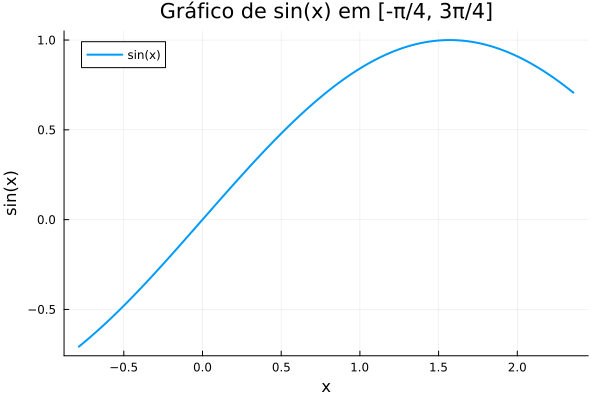

In [ ]:
x = range(-π/4, 3π/4, length=400)
y = sin.(x)

plot(x, y,
    xlabel = "x",
    ylabel = "sin(x)",
    title = "Gráfico de sin(x) em [-π/4, 3π/4]",
    label = "sin(x)",
    lw = 2)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

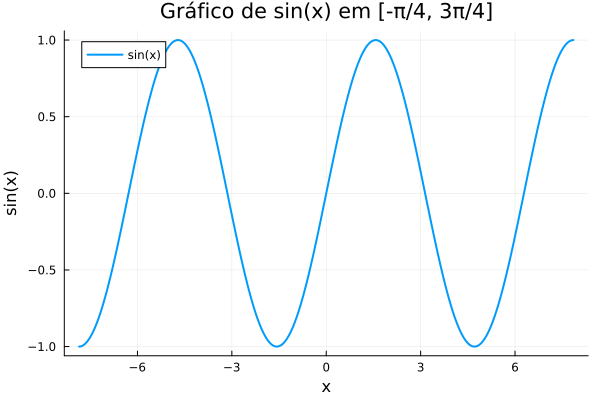

In [8]:
x = range(-10π/4, 10π/4, length=400)
y = sin.(x)

plot(x, y,
    xlabel = "x",
    ylabel = "sin(x)",
    title = "Gráfico de sin(x) em [-π/4, 3π/4]",
    label = "sin(x)",
    lw = 2)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  '

In [15]:
function solve_cylinder(N, c1, c2)
    model = Model(Ipopt.Optimizer)
    set_silent(model)

    @variable(model, r >= 0.0001)
    @variable(model, h >= 0.0001)

    @constraint(model, π * r^2 * h == N)
    @objective(model, Min, c1 * (2π * r * h) + c2 * (2π * r^2))

    optimize!(model)

    return value(r), value(h), objective_value(model)
end


solve_cylinder (generic function with 1 method)

In [13]:
r, h, cost = solve_cylinder(10.0, 2.0, 0.5)

println("r = ", r)
println("h = ", h)
println("cost = ", cost)

r = 1.8533610895586836
h = 0.9266805448869526
cost = 32.37361587857893


# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [ ]:

function solve_awning(h, w; x0=1.0, y0=1.0)
    model = Model(Ipopt.Optimizer)
    set_silent(model)

    @variable(model, x >= 1e-6, start = x0)
    @variable(model, y >= 1e-6, start = y0)

    @NLobjective(model, Min, sqrt(x^2 + y^2))
    @NLconstraint(model, y - w * y / x >= h)

    optimize!(model)

    x_opt = value(x)
    y_opt = value(y)
    z_opt = objective_value(model)

    return x_opt, y_opt, z_opt
end


x ótimo = 5.289428478583722
y ótimo = 4.620741382379412
z ótimo = 7.0234823665248935


In [18]:
x, y, z = solve_awning(2.0, 3.0, x0=1.0, y0=1.0)

println("x ótimo = ", x)
println("y ótimo = ", y)
println("z ótimo = ", z)

x ótimo = 5.289428478583722
y ótimo = 4.620741382379412
z ótimo = 7.0234823665248935


# Problem Statement

Solve the Packing Problem

In [20]:

model = Model(Ipopt.Optimizer)

@variable(model, h >= 0, start = 1.0)
@variable(model, w >= 0, start = 1.0)
@variable(model, d >= 0, start = 1.0)

@objective(model, Max, h * w * d)

@constraint(model, 2*w*h + 2*d*h + 6*w*d <= 60)

optimize!(model)

println("Status = ", termination_status(model))
println("h = ", value(h))
println("w = ", value(w))
println("d = ", value(d))
println("z = ", objective_value(model))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        6
Number of nonzeros in Lagrangian Hessian.............:        9

Total number of variables............................:        3
                     variables with only lower bounds:        3
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0000000e+00 0.00e+00 8.69e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

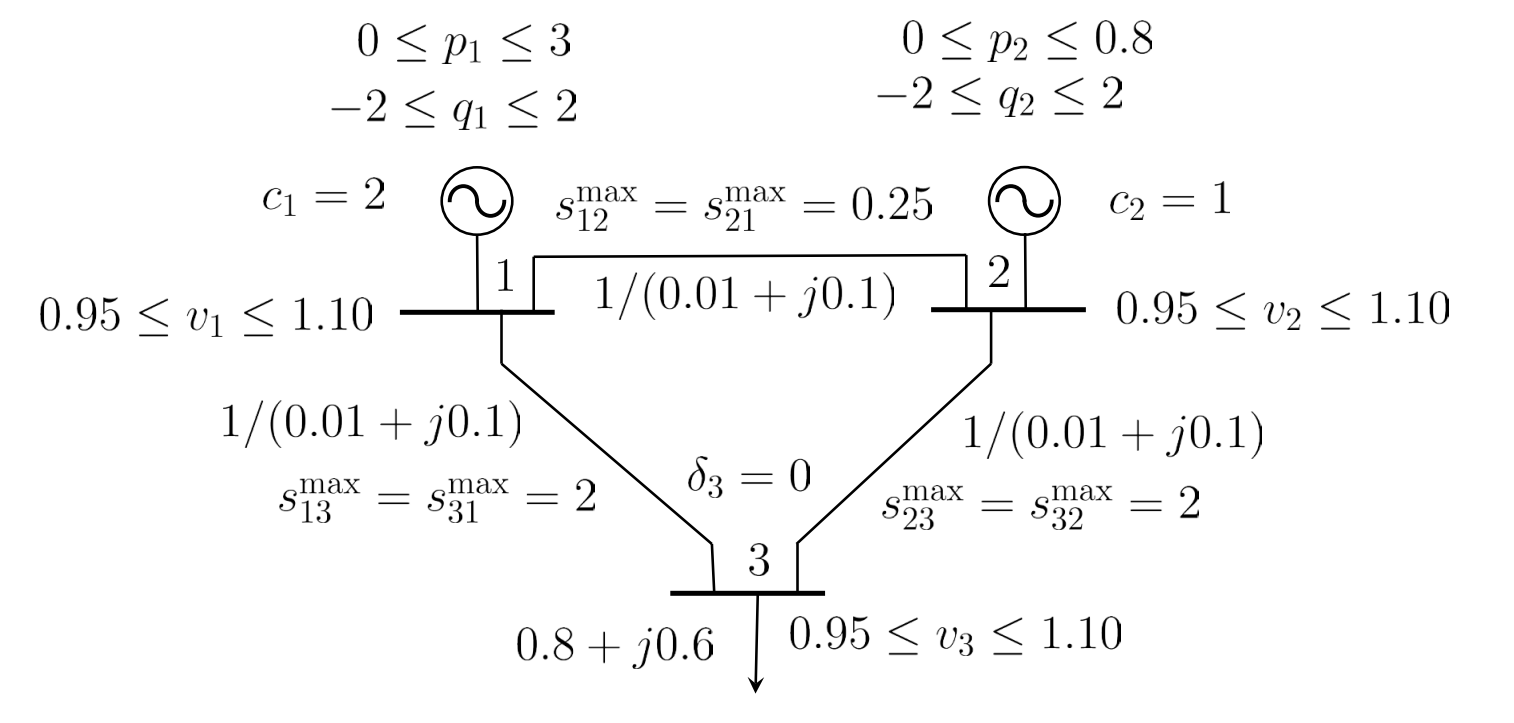

In [7]:

function solve_opf_3bus()
    model = Model(Ipopt.Optimizer)
    set_silent(model)

    # ----------------------------
    # Dados do sistema
    # ----------------------------
    z = 0.01 + 0.1im
    y = 1 / z

    g = real(y)
    b = imag(y)

    # Ybus
    G11 = 2g
    B11 = 2b
    G22 = 2g
    B22 = 2b
    G33 = 2g
    B33 = 2b
    G12 = -g
    B12 = -b
    G13 = -g
    B13 = -b
    G23 = -g
    B23 = -b
    # carga na barra 3
    Pd3 = 0.8
    Qd3 = 0.6

    # ----------------------------
    # Variáveis
    # ----------------------------
    @variable(model, 0 <= p1 <= 3, start = 0.5)
    @variable(model, -2 <= q1 <= 2, start = 0.0)
    @variable(model, 0 <= p2 <= 0.8, start = 0.5)
    @variable(model, -2 <= q2 <= 2, start = 0.0)
    @variable(model, 0.95 <= v1 <= 1.10, start = 1.0)
    @variable(model, 0.95 <= v2 <= 1.10, start = 1.0)
    @variable(model, 0.95 <= v3 <= 1.10, start = 1.0)
    @variable(model, -pi <= d1 <= pi, start = 0.0)
    @variable(model, -pi <= d2 <= pi, start = 0.0)

    # barra slack
    d3 = 0.0

    # ----------------------------
    # Equações de potência por barra
    # ----------------------------

    # Barra 1
    @NLconstraint(model,
        p1 ==
        v1^2 * G11 +
        v1*v2 * (G12*cos(d1-d2) + B12*sin(d1-d2)) +
        v1*v3 * (G13*cos(d1-d3) + B13*sin(d1-d3))
    )

    @NLconstraint(model,
        q1 ==
        -v1^2 * B11 +
        v1*v2 * (G12*sin(d1-d2) - B12*cos(d1-d2)) +
        v1*v3 * (G13*sin(d1-d3) - B13*cos(d1-d3))
    )

    # Barra 2
    @NLconstraint(model,
        p2 ==
        v2^2 * G22 +
        v2*v1 * (G12*cos(d2-d1) + B12*sin(d2-d1)) +
        v2*v3 * (G23*cos(d2-d3) + B23*sin(d2-d3))
    )

    @NLconstraint(model,
        q2 ==
        -v2^2 * B22 +
        v2*v1 * (G12*sin(d2-d1) - B12*cos(d2-d1)) +
        v2*v3 * (G23*sin(d2-d3) - B23*cos(d2-d3))
    )

    # Barra 3
    @NLconstraint(model,
        -Pd3 ==
        v3^2 * G33 +
        v3*v1 * (G13*cos(d3-d1) + B13*sin(d3-d1)) +
        v3*v2 * (G23*cos(d3-d2) + B23*sin(d3-d2))
    )

    @NLconstraint(model,
        -Qd3 ==
        -v3^2 * B33 +
        v3*v1 * (G13*sin(d3-d1) - B13*cos(d3-d1)) +
        v3*v2 * (G23*sin(d3-d2) - B23*cos(d3-d2))
    )

    # ----------------------------
    # Fluxos nas linhas
    # ----------------------------

    # Pij e Qij
    # linha 1-2
    @NLexpression(model, P12,
        g*v1^2 - v1*v2*(g*cos(d1-d2) + b*sin(d1-d2))
    )
    @NLexpression(model, Q12,
        -b*v1^2 - v1*v2*(g*sin(d1-d2) - b*cos(d1-d2))
    )

    @NLexpression(model, P21,
        g*v2^2 - v2*v1*(g*cos(d2-d1) + b*sin(d2-d1))
    )
    @NLexpression(model, Q21,
        -b*v2^2 - v2*v1*(g*sin(d2-d1) - b*cos(d2-d1))
    )

    # linha 1-3
    @NLexpression(model, P13,
        g*v1^2 - v1*v3*(g*cos(d1-d3) + b*sin(d1-d3))
    )
    @NLexpression(model, Q13,
        -b*v1^2 - v1*v3*(g*sin(d1-d3) - b*cos(d1-d3))
    )

    @NLexpression(model, P31,
        g*v3^2 - v3*v1*(g*cos(d3-d1) + b*sin(d3-d1))
    )
    @NLexpression(model, Q31,
        -b*v3^2 - v3*v1*(g*sin(d3-d1) - b*cos(d3-d1))
    )

    # linha 2-3
    @NLexpression(model, P23,
        g*v2^2 - v2*v3*(g*cos(d2-d3) + b*sin(d2-d3))
    )
    @NLexpression(model, Q23,
        -b*v2^2 - v2*v3*(g*sin(d2-d3) - b*cos(d2-d3))
    )

    @NLexpression(model, P32,
        g*v3^2 - v3*v2*(g*cos(d3-d2) + b*sin(d3-d2))
    )
    @NLexpression(model, Q32,
        -b*v3^2 - v3*v2*(g*sin(d3-d2) - b*cos(d3-d2))
    )


    # Restrições
    @NLconstraint(model, P12^2 + Q12^2 <= 0.25^2)
    @NLconstraint(model, P21^2 + Q21^2 <= 0.25^2)

    @NLconstraint(model, P13^2 + Q13^2 <= 2.0^2)
    @NLconstraint(model, P31^2 + Q31^2 <= 2.0^2)

    @NLconstraint(model, P23^2 + Q23^2 <= 2.0^2)
    @NLconstraint(model, P32^2 + Q32^2 <= 2.0^2)

    # Função objetivo
    @objective(model, Min, 2p1 + p2)
    optimize!(model)

    println("Status = ", termination_status(model))
    println("Custo ótimo = ", objective_value(model))
    println()

    println("p1 = ", value(p1))
    println("q1 = ", value(q1))
    println("p2 = ", value(p2))
    println("q2 = ", value(q2))
    println()

    println("v1 = ", value(v1))
    println("v2 = ", value(v2))
    println("v3 = ", value(v3))
    println()

    println("d1 = ", value(d1))
    println("d2 = ", value(d2))
    println("d3 = ", d3)
    println()

    println("S12 = ", sqrt(value(P12)^2 + value(Q12)^2))
    println("S21 = ", sqrt(value(P21)^2 + value(Q21)^2))
    println("S13 = ", sqrt(value(P13)^2 + value(Q13)^2))
    println("S31 = ", sqrt(value(P31)^2 + value(Q31)^2))
    println("S23 = ", sqrt(value(P23)^2 + value(Q23)^2))
    println("S32 = ", sqrt(value(P32)^2 + value(Q32)^2))

    return model
end

model = solve_opf_3bus()

Status = LOCALLY_SOLVED
Custo ótimo = 0.8360786945615211

p1 = 0.030906834553261445
q1 = 0.3209166923859801
p2 = 0.7742650254549982
q2 = 0.33080190769662093

v1 = 1.0977001927052614
v2 = 1.0999998938295108
v3 = 1.066359131642273

d1 = 0.021231966882032355
d2 = 0.04191265995565187
d3 = 0.0

S12 = 0.24947735886869643
S21 = 0.25000001830383006
S13 = 0.42442390470834995
S31 = 0.41230593697685647
S23 = 0.6183879970056234
S32 = 0.5994761374105418


A JuMP Model
├ solver: Ipopt
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 9
├ num_constraints: 30
│ ├ VariableRef in MOI.GreaterThan{Float64}: 9
│ ├ VariableRef in MOI.LessThan{Float64}: 9
│ └ Nonlinear: 12
└ Names registered in the model
  └ :P12, :P13, :P21, :P23, :P31, :P32, :Q12, :Q13, :Q21, :Q23, :Q31, :Q32, :d1, :d2, :p1, :p2, :q1, :q2, :v1, :v2, :v3

# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [13]:
import MathOptInterface as MOI

function solve_regression()

    x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
    x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
    x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
    y  = [2.0, 3.9, 6.1, 8.0, 9.8]

    n = length(y)

    model = Model(Ipopt.Optimizer)
    set_silent(model)

    @variable(model, b0)
    @variable(model, b1)
    @variable(model, b2)
    @variable(model, b3)

    @objective(model, Min,
        sum((b0 + b1*x1[i] + b2*x2[i] + b3*x3[i] - y[i])^2 for i in 1:n)
    )

    optimize!(model)

    status = termination_status(model)
    println("Status = ", status)

    if status == MOI.OPTIMAL || status == MOI.LOCALLY_SOLVED
        b0v = value(b0)
        b1v = value(b1)
        b2v = value(b2)
        b3v = value(b3)

        println("b0 = ", b0v)
        println("b1 = ", b1v)
        println("b2 = ", b2v)
        println("b3 = ", b3v)

        println()
        println("Modelo ajustado:")
        println("y = ", b0v, " + ", b1v, "*x1 + ", b2v, "*x2 + ", b3v, "*x3")

        println()
        println("Valores previstos:")
        for i in 1:n
            y_pred = b0v + b1v*x1[i] + b2v*x2[i] + b3v*x3[i]
            println("obs ", i, ": y = ", y[i], " | y_pred = ", y_pred)
        end

        println()
        println("SSE = ", objective_value(model))
    else
        println("O modelo nao encontrou uma solucao utilizavel.")
    end

    return model
end

model = solve_regression()

Status = LOCALLY_SOLVED
b0 = -0.28545454545464444
b1 = -0.72736050900259
b2 = 4.036539199822912
b3 = 0.818181818182085

Modelo ajustado:
y = -0.28545454545464444 + -0.72736050900259*x1 + 4.036539199822912*x2 + 0.818181818182085*x3

Valores previstos:
obs 1: y = 2.0 | y_pred = 1.9872727272727237
obs 2: y = 3.9 | y_pred = 4.014545454545466
obs 3: y = 6.1 | y_pred = 5.960000000000001
obs 4: y = 8.0 | y_pred = 7.987272727272743
obs 5: y = 9.8 | y_pred = 9.850909090909068

SSE = 0.03563636363639233


A JuMP Model
├ solver: Ipopt
├ objective_sense: MIN_SENSE
│ └ objective_function_type: QuadExpr
├ num_variables: 4
├ num_constraints: 0
└ Names registered in the model
  └ :b0, :b1, :b2, :b3

# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [17]:
function solve_allocation()
    E = 1:3
    P = 1:4

    score = [
        90 80 10 50
        60 70 50 65
        70 40 80 85
    ]

    R = [70, 50, 85, 35]
    Hmax = 80

    model = Model(HiGHS.Optimizer)

    @variable(model, H[E, P] >= 0)

    @objective(model, Max, sum(score[i,j] * H[i,j] for i in E, j in P))

    @constraint(model, [i in E], sum(H[i,j] for j in P) <= Hmax)
    @constraint(model, [j in P], sum(H[i,j] for i in E) == R[j])

    optimize!(model)

    println("Status = ", termination_status(model))
    println("Objective value = ", objective_value(model))
    println()

    for i in E
        for j in P
            println("H[", i, ",", j, "] = ", value(H[i,j]))
        end
    end

    return model
end

solve_allocation()

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros  0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros  0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time 

A JuMP Model
├ solver: HiGHS
├ objective_sense: MAX_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 12
├ num_constraints: 19
│ ├ AffExpr in MOI.EqualTo{Float64}: 4
│ ├ AffExpr in MOI.LessThan{Float64}: 3
│ └ VariableRef in MOI.GreaterThan{Float64}: 12
└ Names registered in the model
  └ :H

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [18]:


function solve_diet()

    model = Model(Ipopt.Optimizer)

    @variable(model, y1 >= 0)
    @variable(model, y2 >= 0)
    @variable(model, y3 >= 0)
    @variable(model, y4 >= 0)

    @objective(model, Min, y1 + 0.5*y2 + 2*y3 + 0.3*y4)

    @constraint(model, 100*y1 + 200*y2 + 150*y3 + 70*y4 >= 500)
    @constraint(model, 0.5*y1 + 4*y2 + 8*y3 + 6*y4 >= 50)
    @constraint(model, 2*y1 + 10*y3 >= 100)

    optimize!(model)

    status = termination_status(model)
    println("Status = ", status)

    if status == MOI.OPTIMAL || status == MOI.LOCALLY_SOLVED
        println("Custo minimo = ", objective_value(model))
        println("y1 = ", value(y1))
        println("y2 = ", value(y2))
        println("y3 = ", value(y3))
        println("y4 = ", value(y4))
    else
        println("O modelo nao encontrou uma solucao utilizavel.")
    end

    return model
end

solve_diet()

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       10
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        4
                     variables with only lower bounds:        4
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        3
        inequality constraints with only lower bounds:        3
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  3.7999962e-02 4.95e+02 1.06e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

A JuMP Model
├ solver: Ipopt
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 4
├ num_constraints: 7
│ ├ AffExpr in MOI.GreaterThan{Float64}: 3
│ └ VariableRef in MOI.GreaterThan{Float64}: 4
└ Names registered in the model
  └ :y1, :y2, :y3, :y4

# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [19]:

function solve_knapsack()

    model = Model(HiGHS.Optimizer)

    @variable(model, x1, Bin)
    @variable(model, x2, Bin)
    @variable(model, x3, Bin)

    @objective(model, Max, 120*x1 + 80*x2 + 60*x3)

    @constraint(model, 2*x1 + x2 + x3 <= 3.5)

    optimize!(model)

    status = termination_status(model)
    println("Status = ", status)

    if status == MOI.OPTIMAL
        println("Valor maximo = ", objective_value(model))
        println("x1 = ", value(x1))
        println("x2 = ", value(x2))
        println("x3 = ", value(x3))
    else
        println("O modelo nao encontrou solucao otima.")
    end

    return model
end

solve_knapsack()

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 3 cols, 3 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc.

A JuMP Model
├ solver: HiGHS
├ objective_sense: MAX_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 3
├ num_constraints: 4
│ ├ AffExpr in MOI.LessThan{Float64}: 1
│ └ VariableRef in MOI.ZeroOne: 3
└ Names registered in the model
  └ :x1, :x2, :x3